# Análisis de las elecciones presidenciales de Colombia de 2018

## Primera vuelta

Este proyecto realiza un análisis exploratorio de los resultados electorales mediante **Python, Pandas, NumPy, Matplotlib y Seaborn**.

### Objetivos

- Examinar la estructura y calidad del conjunto de datos.
- calcular los votos obtenidos por cada candidato;
- identificar los departamentos y municipios con mayor cantidad de votos;
- determinar el candidato ganador por departamento;
- comparar el comportamiento electoral de las principales ciudades;
- generar visualizaciones e interpretaciones útiles para un portafolio de ciencia de datos.

> **Nota:** los resultados representan la información disponible en el dataset y deben interpretarse dentro del alcance y la estructura de esa fuente.

## 1. Importación de librerías

Se importan las herramientas necesarias para manipular datos y crear visualizaciones. También se establece una configuración visual general para mantener consistencia en las gráficas.

In [2]:
# ======================================
# CARGA Y EXPLORACIÓN INICIAL DEL DATASET
# ======================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

## 2. Carga del dataset

El archivo se encuentra en la carpeta `data`, mientras que este notebook está almacenado en `notebooks`. Por esa razón se utiliza `../data/` para subir un nivel dentro de la estructura del proyecto.

In [3]:
df = pd.read_csv("../data/2018_presidencia_primera_vuelta.dta.csv")

## 3. Exploración inicial

Antes de transformar los datos es necesario conocer su estructura. En esta sección se revisan las primeras filas, los tipos de datos, las estadísticas descriptivas, los valores nulos y los nombres de las columnas.

In [4]:
df.head()

,id_electoral,ano,tipo_eleccion,fecha_eleccion,coddpto,departamento,codmpio,municipio,circunscripcion,codigo_partido,codigo_lista,primer_apellido,segundo_apellido,nombres,votos,curules
0,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180003.0,1,PETRO,URREGO,GUSTAVO FRANCISCO,77067,1
1,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180004.0,2,NaN,NaN,PROMOTORES VOTO EN BLANCO,1847,0
2,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20130001.0,3,DUQUE,MARQUEZ,IVAN,535239,1
3,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180002.0,4,DE LA CALLE,LOMBANA,HUMBERTO,25896,0
4,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20170002.0,5,TRUJILLO,SARMIENTO,JORGE ANTONIO,2197,0


### 3.1 Tipos de datos y cantidad de registros

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_electoral      12725 non-null  int64  
 1   ano               12725 non-null  int64  
 2   tipo_eleccion     12725 non-null  str    
 3   fecha_eleccion    12725 non-null  str    
 4   coddpto           12725 non-null  int64  
 5   departamento      12725 non-null  str    
 6   codmpio           12725 non-null  int64  
 7   municipio         12725 non-null  str    
 8   circunscripcion   12725 non-null  str    
 9   codigo_partido    9284 non-null   float64
 10  codigo_lista      12725 non-null  int64  
 11  primer_apellido   11629 non-null  str    
 12  segundo_apellido  8188 non-null   str    
 13  nombres           9284 non-null   str    
 14  votos             12725 non-null  int64  
 15  curules           12725 non-null  int64  
dtypes: float64(1), int64(7), str(8)
memory usage: 1.6 M

### 3.2 Estadísticas descriptivas

In [6]:
df.describe()

,id_electoral,ano,coddpto,codmpio,codigo_partido,codigo_lista,votos,curules
count,12725.0,12725.0,12725.000000,12725.000000,9.284000e+03,12725.000000,1.272500e+04,12725.000000
mean,120180001.0,2018.0,36.755678,37188.619411,2.017238e+07,273.159450,1.543709e+03,0.187112
std,0.0,0.0,26.401656,26386.350831,1.656939e+04,441.312562,1.935942e+04,0.390017
min,120180001.0,2018.0,5.000000,5001.000000,2.013000e+07,1.000000,1.000000e+00,0.000000
25%,120180001.0,2018.0,15.000000,15401.000000,2.018000e+07,3.000000,1.600000e+01,0.000000
50%,120180001.0,2018.0,25.000000,25612.000000,2.018000e+07,6.000000,7.300000e+01,0.000000
75%,120180001.0,2018.0,63.000000,63272.000000,2.018000e+07,997.000000,4.690000e+02,0.000000
max,120180001.0,2018.0,99.000000,99773.000000,2.018001e+07,999.000000,1.244477e+06,1.000000


### 3.3 Valores faltantes

Los valores nulos no deben eliminarse automáticamente. Primero se debe determinar si representan errores, campos opcionales o categorías electorales que no corresponden a una persona candidata.

In [7]:
df.isnull().sum()

id_electoral           0
ano                    0
tipo_eleccion          0
fecha_eleccion         0
coddpto                0
departamento           0
codmpio                0
municipio              0
circunscripcion        0
codigo_partido      3441
codigo_lista           0
primer_apellido     1096
segundo_apellido    4537
nombres             3441
votos                  0
curules                0
dtype: int64

### 3.4 Nombres de las variables

In [8]:
df.columns

Index(['id_electoral', 'ano', 'tipo_eleccion', 'fecha_eleccion', 'coddpto',
       'departamento', 'codmpio', 'municipio', 'circunscripcion',
       'codigo_partido', 'codigo_lista', 'primer_apellido', 'segundo_apellido',
       'nombres', 'votos', 'curules'],
      dtype='str')

## 4. Preparación de la variable `candidato`

El nombre se encuentra dividido en varias columnas. Para facilitar agrupaciones, filtros y gráficas se crea una nueva variable llamada `candidato`.

`fillna("")` reemplaza temporalmente los valores faltantes por texto vacío y `str.strip()` elimina espacios sobrantes.

In [9]:
# ======================================
# TOTAL DE VOTOS POR CANDIDATO
# ======================================

df["candidato"] = (
    df["nombres"].fillna("") + " " +
    df["primer_apellido"].fillna("") + " " +
    df["segundo_apellido"].fillna("") + " "
).str.strip()

df[["candidato"]].head(10)

,candidato
0,GUSTAVO FRANCISCO PETRO URREGO
1,PROMOTORES VOTO EN BLANCO
2,IVAN DUQUE MARQUEZ
3,HUMBERTO DE LA CALLE LOMBANA
4,JORGE ANTONIO TRUJILLO SARMIENTO
5,SERGIO FAJARDO VALDERRAMA
6,VIVIANE ALEIDA MORALES HOYOS
7,GERMAN VARGAS LLERAS
8,TARJETAS NO MARCADAS
9,VOTOS NULOS


## 5. Total de votos por candidato

Se agrupan los registros por candidato, se suman los votos y se ordenan los resultados de mayor a menor.

La operación sigue este flujo:

1. `groupby("candidato")`: crea un grupo para cada candidato;
2. `["votos"]`: selecciona la variable que será agregada;
3. `.sum()`: suma los votos de cada grupo;
4. `.sort_values(ascending=False)`: ordena de mayor a menor.

In [10]:


votes_by_candidate = (
    df.groupby("candidato")["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_by_candidate

candidato
IVAN DUQUE MARQUEZ                  7617114
GUSTAVO FRANCISCO PETRO URREGO      4854831
SERGIO FAJARDO VALDERRAMA           4602916
GERMAN VARGAS LLERAS                1412392
HUMBERTO DE LA CALLE LOMBANA         396151
VOTOS EN BLANCO                      338581
VOTOS NULOS                          242002
JORGE ANTONIO TRUJILLO SARMIENTO      65767
TARJETAS NO MARCADAS                  47675
VIVIANE ALEIDA MORALES HOYOS          36138
PROMOTORES VOTO EN BLANCO             30128
Name: votos, dtype: int64

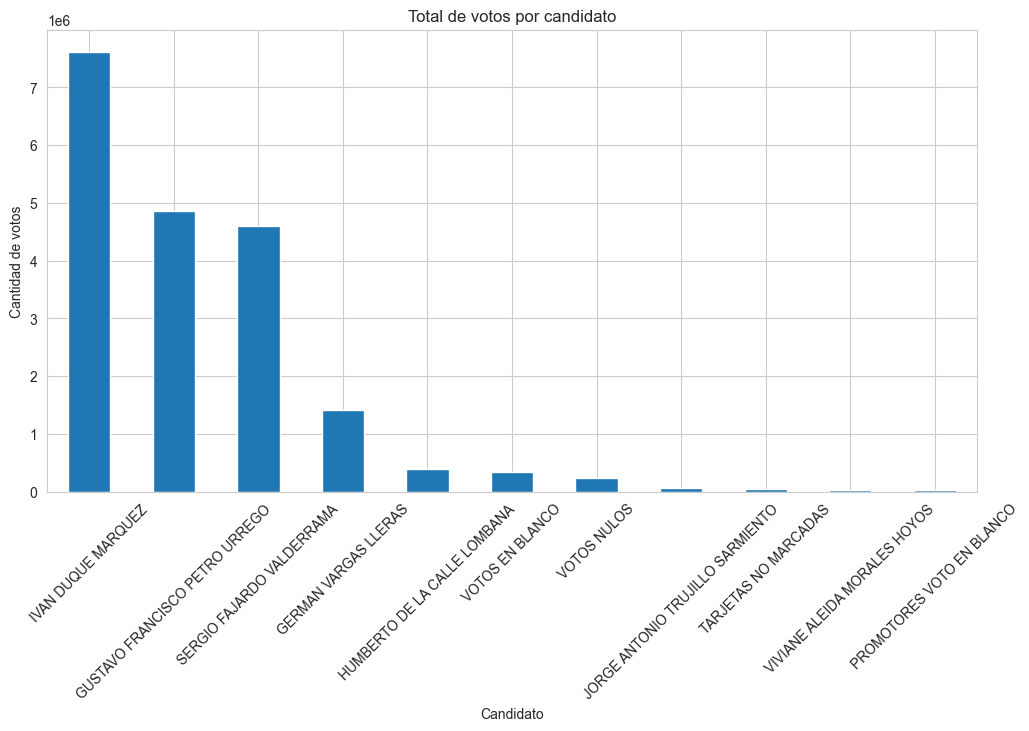

In [11]:
plt.figure(figsize=(12,6))

votes_by_candidate.plot(kind="bar")

plt.title("Total de votos por candidato")
plt.xlabel("Candidato")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

### Interpretación

La gráfica permite comparar rápidamente la magnitud del apoyo electoral de cada candidatura y reconocer categorías como votos en blanco, votos nulos o tarjetas no marcadas cuando estén representadas en el dataset.

Para la versión final del proyecto conviene separar las candidaturas reales de las demás categorías electorales si se desea calcular porcentajes exclusivamente sobre votos válidos.

## 6. Participación porcentual por candidato

Los valores absolutos muestran cuántos votos recibió cada candidatura, pero los porcentajes facilitan la comparación respecto al total registrado en el conjunto de datos.

In [ ]:
candidate_votes = (
    df.groupby("candidato")["votos"]
    .sum()
    .reset_index()
)

total_votes = candidate_votes["votos"].sum()

candidate_votes["porcentaje"] = (
    candidate_votes["votos"] / total_votes
) * 100

candidate_votes = candidate_votes.sort_values(
    "porcentaje",
    ascending=False
)

candidate_votes

La nueva columna `porcentaje` se calcula mediante una operación vectorizada: Pandas divide cada fila de la columna `votos` entre el total y multiplica el resultado por 100, sin necesidad de escribir un ciclo `for`.

## 7. Votos por departamento

Se suman todos los votos registrados en cada departamento para identificar las zonas con mayor peso electoral. La visualización se limita a los diez primeros resultados para evitar una gráfica saturada.

In [12]:
votes_by_department = (
    df.groupby("departamento")["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_by_department

departamento
BOGOTA DC                                                  3705960
ANTIOQUIA                                                  2615238
VALLE DEL CAUCA                                            1780994
CUNDINAMARCA                                               1208999
SANTANDER                                                  1004596
ATLANTICO                                                   873397
BOLIVAR                                                     638517
NORTE DE SANTANDER                                          626915
CORDOBA                                                     597614
TOLIMA                                                      584488
BOYACA                                                      561691
NARINO                                                      525215
CAUCA                                                       482000
HUILA                                                       456879
CALDAS                                           

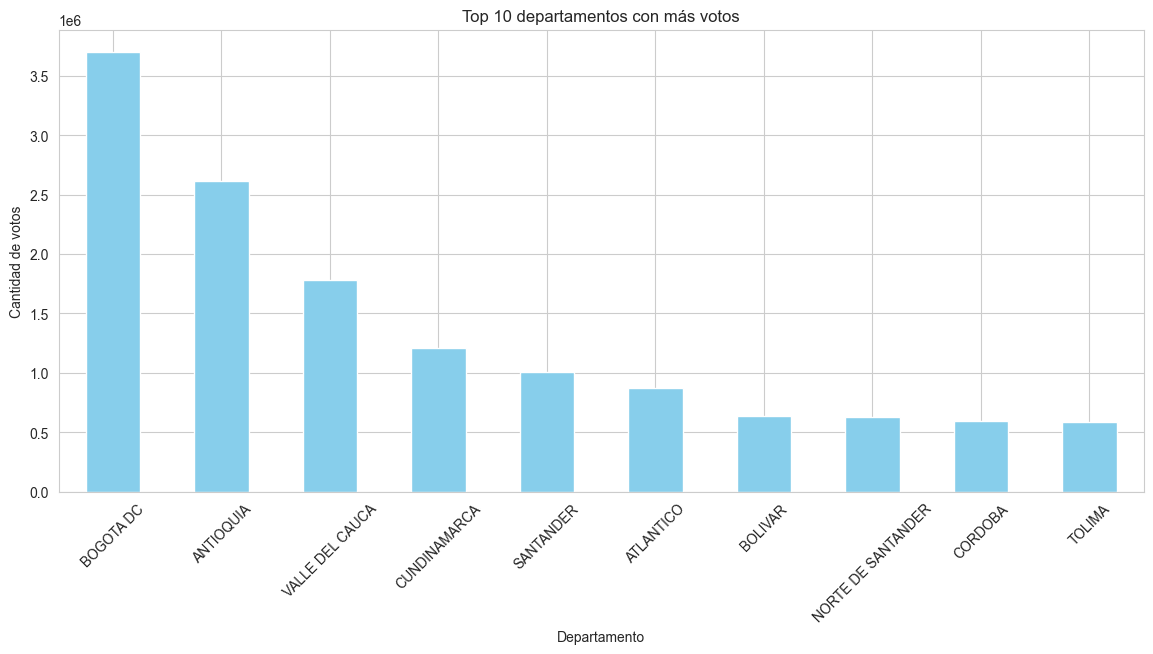

In [13]:
plt.figure(figsize=(14,6))

votes_by_department.head(10).plot(kind="bar", color="skyblue")

plt.title("Top 10 departamentos con más votos")
plt.xlabel("Departamento")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

### Interpretación

Los territorios con mayor población electoral concentran una parte considerable de los votos. Esta gráfica refleja volumen total, no preferencia por un candidato específico.

## 8. Resultado por candidato y departamento

Ahora se utilizan dos variables de agrupación: `departamento` y `candidato`. Esto permite calcular cuántos votos obtuvo cada candidatura dentro de cada territorio.

In [14]:
votes_candidate_department = (
    df.groupby(["departamento", "candidato"])["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_candidate_department

departamento                                             candidato                     
ANTIOQUIA                                                IVAN DUQUE MARQUEZ                1375965
BOGOTA DC                                                SERGIO FAJARDO VALDERRAMA         1244477
                                                         GUSTAVO FRANCISCO PETRO URREGO    1099955
                                                         IVAN DUQUE MARQUEZ                 989744
ANTIOQUIA                                                SERGIO FAJARDO VALDERRAMA          732993
                                                                                            ...   
AMAZONAS                                                 PROMOTORES VOTO EN BLANCO              20
ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA  PROMOTORES VOTO EN BLANCO              18
                                                         TARJETAS NO MARCADAS                   15
GUAINIA              

### 8.1 Conversión del resultado a un DataFrame

Después de agrupar, `departamento` y `candidato` forman un índice múltiple. `reset_index()` los devuelve como columnas normales para facilitar filtros, ordenamientos y visualizaciones posteriores.

In [15]:
winner_by_department = (
    df.groupby(["departamento", "candidato"])["votos"]
    .sum()
    .reset_index()
)
winner_by_department.head()

,departamento,candidato,votos
0,AMAZONAS,GERMAN VARGAS LLERAS,1308
1,AMAZONAS,GUSTAVO FRANCISCO PETRO URREGO,5931
2,AMAZONAS,HUMBERTO DE LA CALLE LOMBANA,739
3,AMAZONAS,IVAN DUQUE MARQUEZ,7104
4,AMAZONAS,JORGE ANTONIO TRUJILLO SARMIENTO,87


### 8.2 Identificación del ganador por departamento

Primero se ordenan los resultados por número de votos. Después, `drop_duplicates()` conserva la primera aparición de cada departamento, que corresponde al candidato con mayor votación debido al orden descendente.

In [16]:
winner_by_department = (
    winner_by_department
    .sort_values("votos", ascending=False)
)

In [17]:
winners = winner_by_department.drop_duplicates(
    subset="departamento",
    keep="first"
)

winners

,departamento,candidato,votos
14,ANTIOQUIA,IVAN DUQUE MARQUEZ,1375965
61,BOGOTA DC,SERGIO FAJARDO VALDERRAMA,1244477
344,VALLE DEL CAUCA,IVAN DUQUE MARQUEZ,527622
179,CUNDINAMARCA,IVAN DUQUE MARQUEZ,479936
311,SANTANDER,IVAN DUQUE MARQUEZ,442219
267,NORTE DE SANTANDER,IVAN DUQUE MARQUEZ,378192
45,ATLANTICO,GUSTAVO FRANCISCO PETRO URREGO,331979
333,TOLIMA,IVAN DUQUE MARQUEZ,285470
69,BOLIVAR,IVAN DUQUE MARQUEZ,258540
166,CORDOBA,GUSTAVO FRANCISCO PETRO URREGO,250437


### 8.3 Cantidad de departamentos ganados

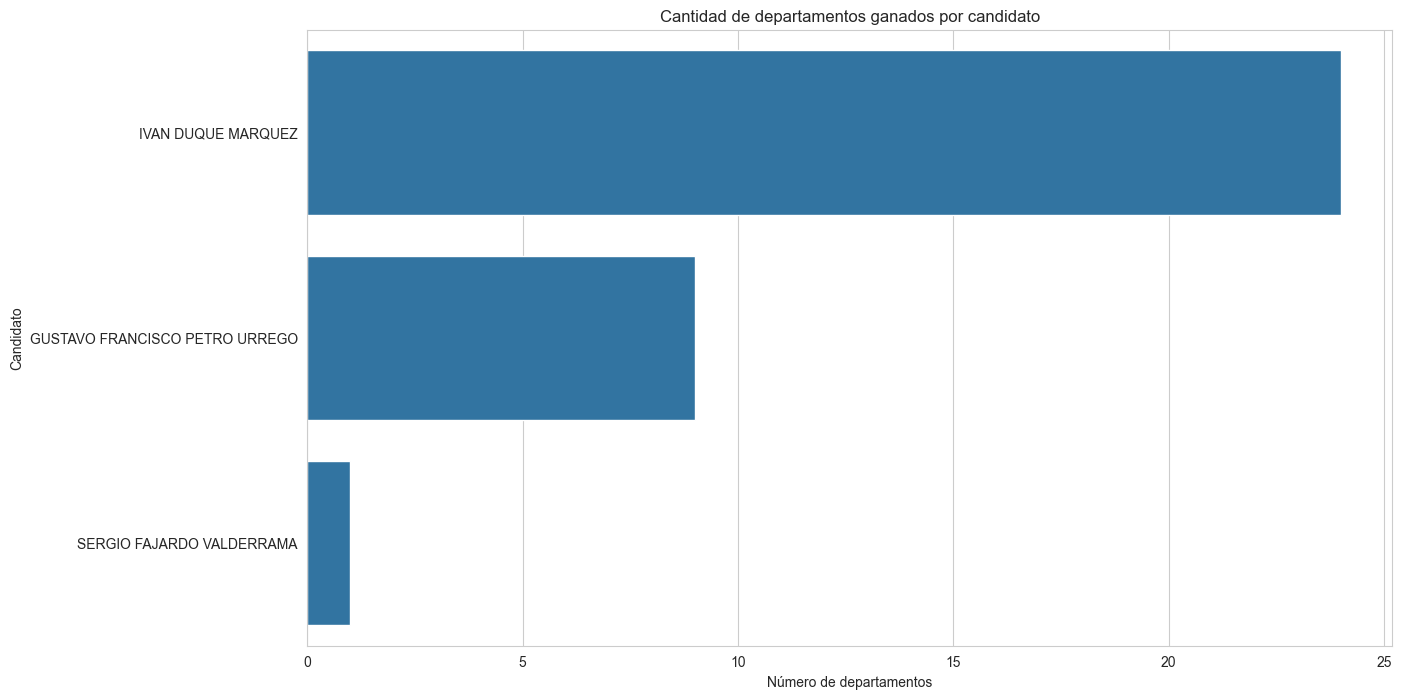

In [18]:
plt.figure(figsize=(14,8))

sns.countplot(
    data=winners,
    y="candidato",
    order=winners["candidato"].value_counts().index
)

plt.title("Cantidad de departamentos ganados por candidato")
plt.xlabel("Número de departamentos")
plt.ylabel("Candidato")

plt.show()

Esta visualización cuenta cuántas veces aparece cada candidatura en la tabla de ganadores. Debe interpretarse como **cobertura territorial**, no como porcentaje nacional de votos.

### 8.4 Consultas específicas

Los siguientes filtros permiten revisar qué departamentos fueron ganados por candidaturas concretas. El resultado booleano selecciona únicamente las filas que cumplen la condición.

In [19]:
winners[winners["candidato"] == "SERGIO FAJARDO VALDERRAMA"]

,departamento,candidato,votos
61,BOGOTA DC,SERGIO FAJARDO VALDERRAMA,1244477


In [20]:
winners[winners["candidato"] == "IVAN DUQUE MARQUEZ"]

,departamento,candidato,votos
14,ANTIOQUIA,IVAN DUQUE MARQUEZ,1375965
344,VALLE DEL CAUCA,IVAN DUQUE MARQUEZ,527622
179,CUNDINAMARCA,IVAN DUQUE MARQUEZ,479936
311,SANTANDER,IVAN DUQUE MARQUEZ,442219
267,NORTE DE SANTANDER,IVAN DUQUE MARQUEZ,378192
333,TOLIMA,IVAN DUQUE MARQUEZ,285470
69,BOLIVAR,IVAN DUQUE MARQUEZ,258540
212,HUILA,IVAN DUQUE MARQUEZ,241612
80,BOYACA,IVAN DUQUE MARQUEZ,227676
245,META,IVAN DUQUE MARQUEZ,212158


In [21]:
winners[winners["candidato"] == "GUSTAVO FRANCISCO PETRO URREGO"]

,departamento,candidato,votos
45,ATLANTICO,GUSTAVO FRANCISCO PETRO URREGO,331979
166,CORDOBA,GUSTAVO FRANCISCO PETRO URREGO,250437
254,NARINO,GUSTAVO FRANCISCO PETRO URREGO,239124
122,CAUCA,GUSTAVO FRANCISCO PETRO URREGO,231470
320,SUCRE,GUSTAVO FRANCISCO PETRO URREGO,154801
221,LA GUAJIRA,GUSTAVO FRANCISCO PETRO URREGO,85523
276,PUTUMAYO,GUSTAVO FRANCISCO PETRO URREGO,60683
144,CHOCO,GUSTAVO FRANCISCO PETRO URREGO,49966
353,VAUPES,GUSTAVO FRANCISCO PETRO URREGO,2514


## 9. Municipios con mayor cantidad de votos

Se agregan los votos por municipio y se muestran los diez con mayor volumen electoral.

In [22]:
votes_by_city = (
    df.groupby("municipio")["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_by_city.head(10)

municipio
BOGOTA DC              3705960
MEDELLIN               1009878
CALI                    883217
BARRANQUILLA            501970
SAN JOSE DE CUCUTA      320722
BUCARAMANGA             306948
CARTAGENA DE INDIAS     304264
IBAGUE                  255315
PEREIRA                 234395
VILLAVICENCIO           225253
Name: votos, dtype: int64

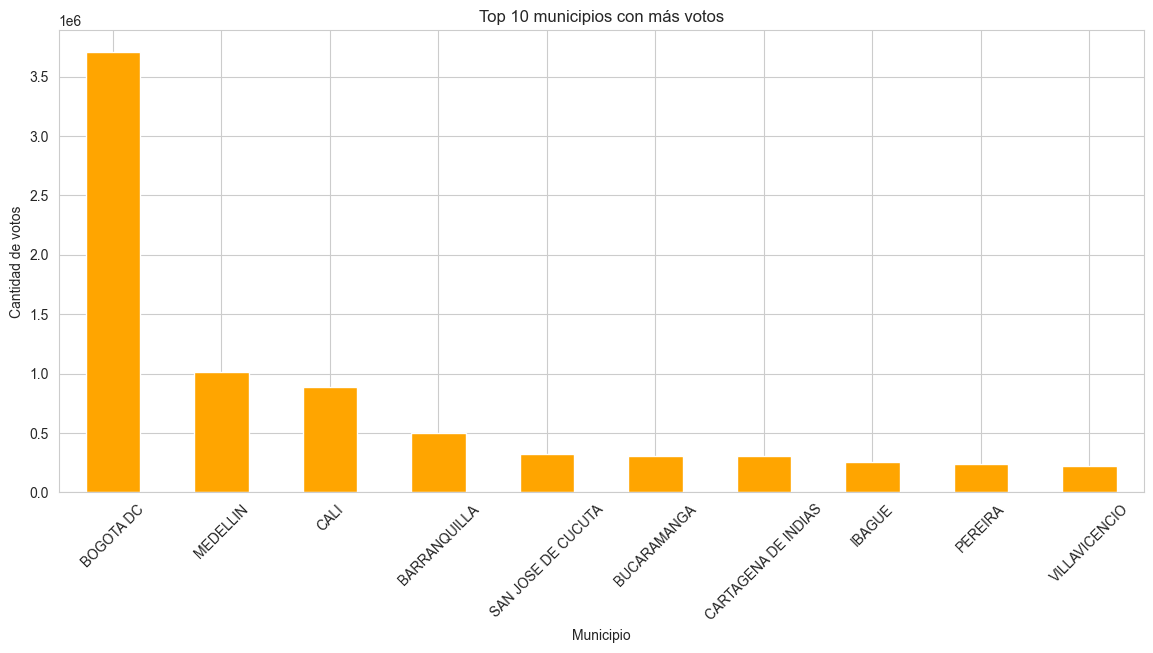

In [23]:
plt.figure(figsize=(14,6))

votes_by_city.head(10).plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 municipios con más votos")
plt.xlabel("Municipio")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

### Interpretación

La gráfica evidencia la concentración del voto en las principales ciudades. El volumen electoral puede estar relacionado con población habilitada, participación y características territoriales; no debe confundirse directamente con población total.

## 10. Principales ciudades

Se seleccionan cinco ciudades mediante `.isin()`. Este método comprueba si cada valor de la columna `municipio` pertenece a la lista definida en `top_cities`.

In [24]:
top_cities = [
    "BOGOTA DC",
    "MEDELLIN",
    "CALI",
    "BARRANQUILLA",
    "SAN JOSE DE CUCUTA"
]

top_cities_df = df[df["municipio"].isin(top_cities)]

top_cities_df.head()

,id_electoral,ano,tipo_eleccion,fecha_eleccion,coddpto,departamento,codmpio,municipio,circunscripcion,codigo_partido,codigo_lista,primer_apellido,segundo_apellido,nombres,votos,curules,candidato
0,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180003.0,1,PETRO,URREGO,GUSTAVO FRANCISCO,77067,1,GUSTAVO FRANCISCO PETRO URREGO
1,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180004.0,2,NaN,NaN,PROMOTORES VOTO EN BLANCO,1847,0,PROMOTORES VOTO EN BLANCO
2,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20130001.0,3,DUQUE,MARQUEZ,IVAN,535239,1,IVAN DUQUE MARQUEZ
3,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180002.0,4,DE LA CALLE,LOMBANA,HUMBERTO,25896,0,HUMBERTO DE LA CALLE LOMBANA
4,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20170002.0,5,TRUJILLO,SARMIENTO,JORGE ANTONIO,2197,0,JORGE ANTONIO TRUJILLO SARMIENTO


### 10.1 Ganador en cada ciudad

Se suman los votos por municipio y candidato. Después se ordenan y se conserva únicamente la candidatura con mayor votación dentro de cada ciudad.

In [25]:
city_winners = (
    top_cities_df
    .groupby(["municipio", "candidato"])["votos"]
    .sum()
    .reset_index()
)

city_winners.head()

,municipio,candidato,votos
0,BARRANQUILLA,GERMAN VARGAS LLERAS,79653
1,BARRANQUILLA,GUSTAVO FRANCISCO PETRO URREGO,188185
2,BARRANQUILLA,HUMBERTO DE LA CALLE LOMBANA,8635
3,BARRANQUILLA,IVAN DUQUE MARQUEZ,144321
4,BARRANQUILLA,JORGE ANTONIO TRUJILLO SARMIENTO,1958


In [26]:
city_winners = city_winners.sort_values(
    "votos",
    ascending=False
)

city_winners = city_winners.drop_duplicates(
    subset="municipio",
    keep="first"
)

city_winners

,municipio,candidato,votos
17,BOGOTA DC,SERGIO FAJARDO VALDERRAMA,1244477
36,MEDELLIN,IVAN DUQUE MARQUEZ,535239
28,CALI,SERGIO FAJARDO VALDERRAMA,284347
47,SAN JOSE DE CUCUTA,IVAN DUQUE MARQUEZ,191221
1,BARRANQUILLA,GUSTAVO FRANCISCO PETRO URREGO,188185


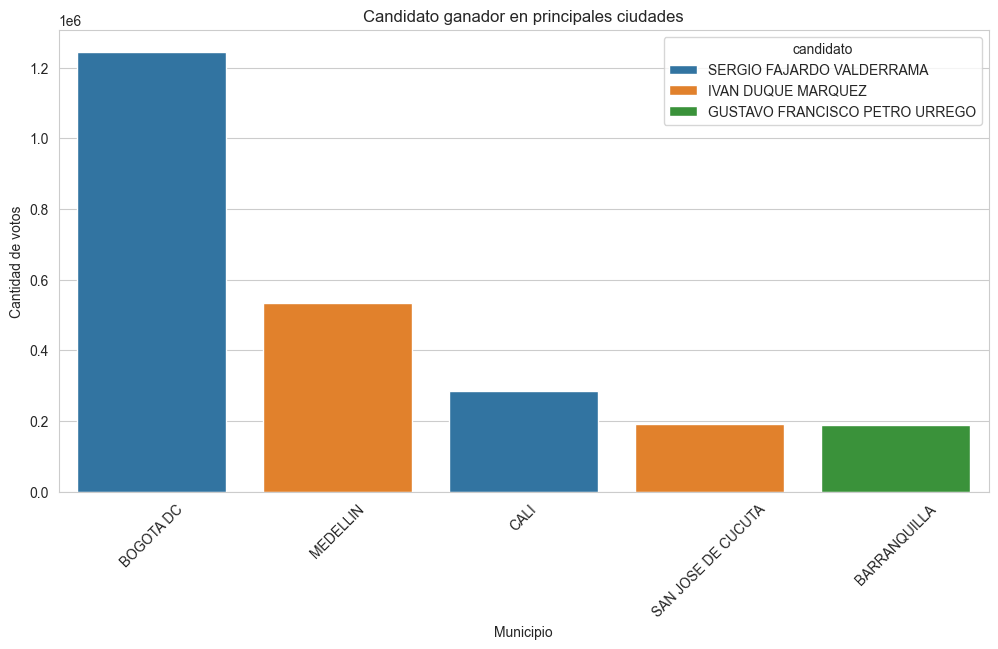

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=city_winners,
    x="municipio",
    y="votos",
    hue="candidato"
)

plt.title("Candidato ganador en principales ciudades")
plt.xlabel("Municipio")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

En esta gráfica, `hue="candidato"` utiliza colores diferentes para distinguir la candidatura ganadora de cada ciudad.

## 11. Comparación de todos los candidatos en las principales ciudades

A diferencia del análisis anterior, aquí no se eliminan las candidaturas perdedoras. Esto permite comparar la distribución completa de votos dentro de cada ciudad.

In [32]:
city_results = (
    top_cities_df
    .groupby(["municipio", "candidato"])["votos"]
    .sum()
    .reset_index()
)

city_results.head()

,municipio,candidato,votos
0,BARRANQUILLA,GERMAN VARGAS LLERAS,79653
1,BARRANQUILLA,GUSTAVO FRANCISCO PETRO URREGO,188185
2,BARRANQUILLA,HUMBERTO DE LA CALLE LOMBANA,8635
3,BARRANQUILLA,IVAN DUQUE MARQUEZ,144321
4,BARRANQUILLA,JORGE ANTONIO TRUJILLO SARMIENTO,1958


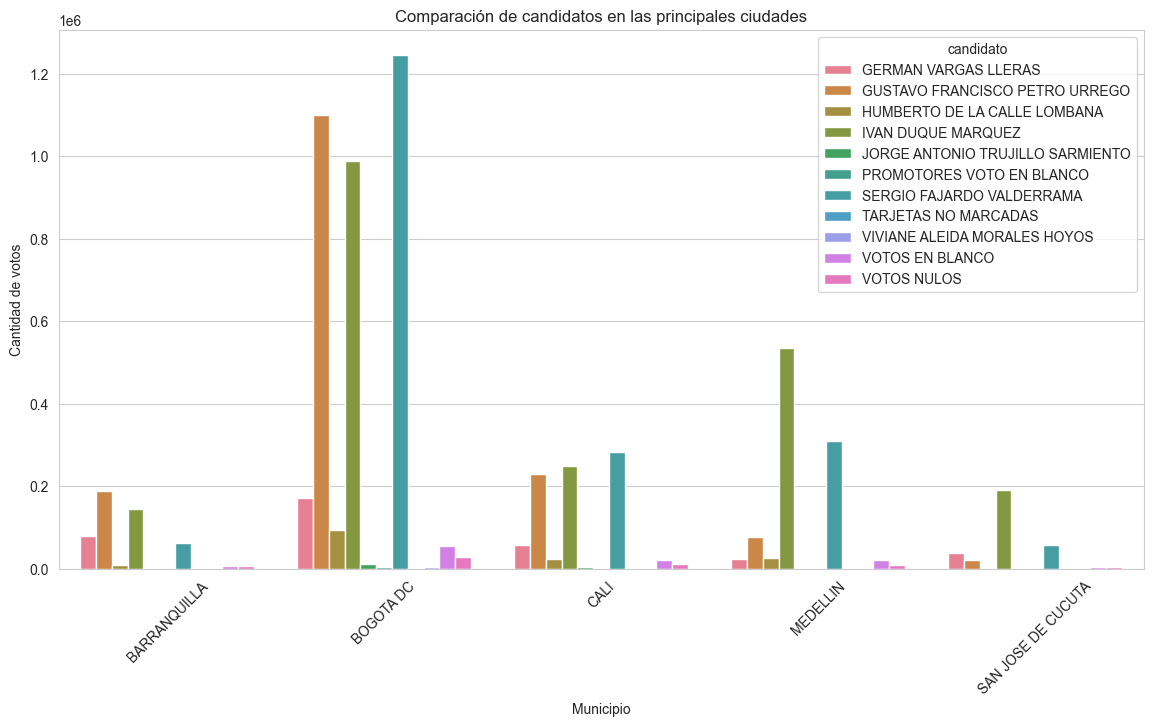

In [33]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=city_results,
    x="municipio",
    y="votos",
    hue="candidato"
)

plt.title("Comparación de candidatos en las principales ciudades")
plt.xlabel("Municipio")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()


### Interpretación

`hue="candidato"` añade una dimensión categórica por color. Así, dentro de cada municipio se pueden comparar varias candidaturas y reconocer diferencias regionales en el comportamiento electoral.

La gráfica puede resultar cargada si incluye categorías no asociadas a candidatos. En una etapa posterior puede crearse una variable que diferencie entre:

- candidatos;
- voto en blanco;
- votos nulos;
- tarjetas no marcadas;
- otras categorías.

## 12. Conclusiones preliminares

- El voto se encuentra fuertemente concentrado en Bogotá y en las ciudades de mayor tamaño.
- El liderazgo nacional y la cantidad de territorios ganados representan medidas distintas: una candidatura puede ganar numerosos departamentos sin dominar todas las grandes ciudades.
- Las principales ciudades presentan comportamientos electorales diferentes, por lo que el análisis territorial aporta información que no aparece en el resultado nacional agregado.
- La presencia de valores nulos y categorías no asociadas directamente a candidatos requiere una revisión específica antes de calcular indicadores como porcentaje de votos válidos.

## Próximos pasos

1. Separar candidatos de votos en blanco, nulos y tarjetas no marcadas.
2. Calcular porcentajes nacionales, departamentales y municipales.
3. estudiar márgenes de victoria y niveles de competencia;
4. detectar municipios con comportamientos atípicos;
5. exportar las visualizaciones principales para el `README.md`;
6. considerar un mapa electoral y un dashboard interactivo.